В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [163]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import statsmodels.api as sm

# Знайомство з даними

##**Завдання 1.**   
Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cars_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/cars.csv')

In [4]:
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


##**Завдання 2.**  
Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [ ]:
# приклад як викликати документацію, якщо у Вас pandas імпортований як pd
?pd.DataFrame.info

In [5]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [6]:
# Check unisque values for columns with object data type
print("Brand:", cars_df['Brand'].unique())
print("\nModel:", cars_df['Model'].unique())
print("\nFuel_Type:", cars_df['Fuel_Type'].unique())
print("\nTransmission:", cars_df['Transmission'].unique())
print("\nOwner_Type:", cars_df['Owner_Type'].unique())

Brand: ['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes']

Model: ['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport']

Fuel_Type: ['Petrol' 'Diesel']

Transmission: ['Manual' 'Automatic']

Owner_Type: ['First' 'Second' 'Third']


В наборі даних міститься 100 рядків записів, 13 колонок даних.  
Кількість колонок:
- числових: 8 (`Car_ID`, `Year`, `Kilometers_Driven`, `Mileage`, `Engine`, `Power`, `Seats`, `Price`)  

- категоріальних: 5  
    - 2 бінарні (`Fuel_Type`, `Transmission`)
    - 2 мультикатегоріальні (`Brand`, `Model`)
    - 1 категоріальна ординальна (встановлюється порядковість значень) (`Owner_Type`)

##**Завдання 3**.   
Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [7]:
X = cars_df.drop(columns='Price')
y = cars_df['Price']

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=12)

##**Завдання 4**.

Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

###**Кодування категоріальних колонок з бінарними значеннями**

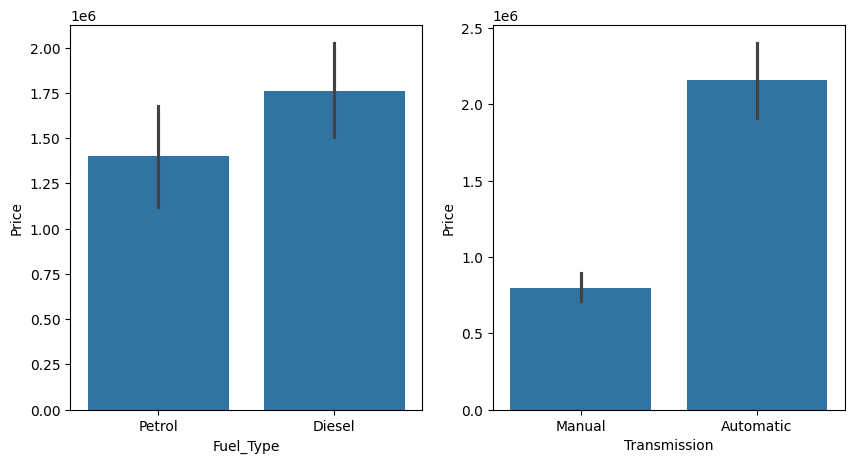

In [67]:
# Checking Fuel type distribution
fig, ax = plt.subplots(1,2, figsize=(10,5))
sns.barplot(cars_df, x='Fuel_Type', y='Price', ax=ax[0])
sns.barplot(cars_df, x='Transmission', y='Price', ax=ax[1])
plt.show()

In [68]:
# Code dicts
fuel_type_codes = {'Petrol':0, 'Diesel':1}
transmission_codes = {'Automatic':0, 'Manual':1}

In [69]:
# Creating coded columns in train set
X_train['Fuel_Type_Code'] = X_train['Fuel_Type'].map(fuel_type_codes)
X_train['Transmission_Code'] = X_train['Transmission'].map(transmission_codes)

# In test set
X_test['Fuel_Type_Code'] = X_test['Fuel_Type'].map(fuel_type_codes)
X_test['Transmission_Code'] = X_test['Transmission'].map(transmission_codes)

In [70]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,0,0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,1,0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,0,0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0,1
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,0,0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,0,0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,0,1
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0,1
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,0,1
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,0,1


(None, None)

###**Кодування категоріальних колонок з One Hot Fit**

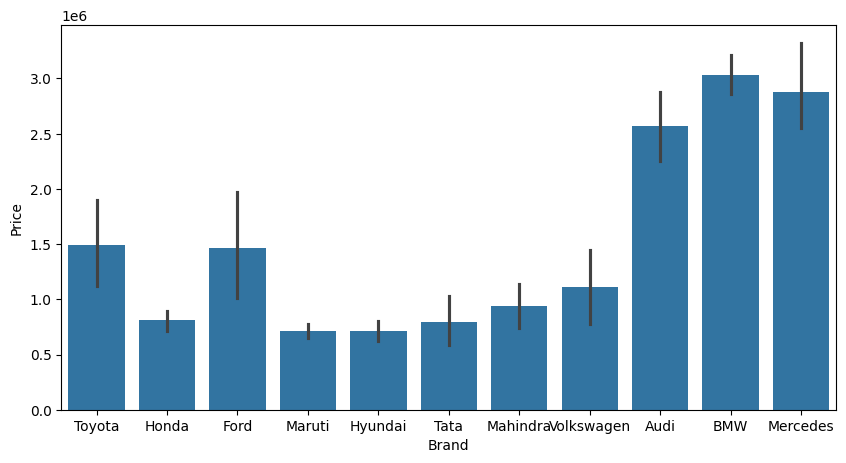

In [71]:
# Checking Brand distribution
plt.figure(figsize=(10,5))
sns.barplot(cars_df, x='Brand', y='Price')
plt.show()

In [72]:
ohe_col = ['Brand']
encoder_ohe = preprocessing.OneHotEncoder()
encoder_ohe.fit(X_train[ohe_col])

OneHotEncoder()

In [73]:
encoder_ohe.categories_[0].tolist()

['Audi',
 'BMW',
 'Ford',
 'Honda',
 'Hyundai',
 'Mahindra',
 'Maruti',
 'Mercedes',
 'Tata',
 'Toyota',
 'Volkswagen']

In [74]:
one_hot_X_train = encoder_ohe.transform(X_train[ohe_col]).toarray()
one_hot_X_test = encoder_ohe.transform(X_test[ohe_col]).toarray()

X_train[encoder_ohe.categories_[0]] = one_hot_X_train
X_test[encoder_ohe.categories_[0]] = one_hot_X_test

In [75]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


(None, None)

###**Кодування категоріальних колонок з Ordinal Encoder**

In [76]:
ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

In [77]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

###**Групування категоріальної колонки Model**

In [78]:
unique_cars = cars_df[['Brand', 'Model']].drop_duplicates()
unique_cars

,Brand,Model
0,Toyota,Corolla
1,Honda,Civic
2,Ford,Mustang
3,Maruti,Swift
4,Hyundai,Sonata
5,Tata,Nexon
6,Mahindra,Scorpio
7,Volkswagen,Polo
8,Audi,A4
9,BMW,X1


In [79]:
# Create the mapping dictionary based on Model
model_mapping = {
    # SUVs
    'Nexon': 'SUV', 'Scorpio': 'SUV', 'X1': 'SUV', 'Endeavour': 'SUV', 'Creta': 'SUV',
    'Harrier': 'SUV', 'Tiguan': 'SUV', 'Q3': 'SUV', 'GLC': 'SUV', 'Thar': 'SUV',
    'X3': 'SUV', 'Fortuner': 'SUV', 'Vitara': 'SUV', 'WR-V': 'SUV', 'S-Cross': 'SUV',
    'BR-V': 'SUV', 'T-Roc': 'SUV', 'Q7': 'SUV', 'X5': 'SUV', 'GLA': 'SUV',
    'Venue': 'SUV', 'XUV300': 'SUV', 'Safari': 'SUV', 'EcoSport': 'SUV', 'GLE': 'SUV',

    # Sedans
    'Corolla': 'Sedan', 'Civic': 'Sedan', 'Sonata': 'Sedan', 'A4': 'Sedan', 'C-Class': 'Sedan',
    'City': 'Sedan', '5 Series': 'Sedan', 'Verna': 'Sedan', 'Passat': 'Sedan', 'A6': 'Sedan',
    'E-Class': 'Sedan', 'Aspire': 'Sedan', 'Elantra': 'Sedan', 'Ameo': 'Sedan', 'A3': 'Sedan',
    '7 Series': 'Sedan', 'Yaris': 'Sedan', 'Tigor': 'Sedan', 'Camry': 'Sedan', 'Vento': 'Sedan',
    'A5': 'Sedan', '3 Series': 'Sedan',

    # Hatchbacks
    'Swift': 'Hatchback', 'Polo': 'Hatchback', 'Figo': 'Hatchback', 'Altroz': 'Hatchback',
    'Santro': 'Hatchback', 'Tiago': 'Hatchback',

    # MPVs / MUVs
    'Ertiga': 'MPV', 'Innova': 'MPV', 'Innova Crysta': 'MPV',

    # Specialty
    'Ranger': 'Pickup', 'Mustang': 'Sports'
}

In [80]:
# Map the models to the new column
X_train['Vehicle_Type'] = X_train['Model'].map(model_mapping)
X_test['Vehicle_Type'] = X_test['Model'].map(model_mapping)

In [81]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Vehicle_Type
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,SUV
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Sedan
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,SUV


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Vehicle_Type
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SUV
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Hatchback
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Sedan
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,MPV
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Sedan


(None, None)

In [82]:
X_train['Vehicle_Type'].unique()

array(['SUV', 'Sedan', 'Hatchback', 'Sports', 'Pickup', 'MPV'],
      dtype=object)

Закодуємо колонку типу авто за принципом One Hot Fit

In [83]:
ohe_col2 = ['Vehicle_Type']
encoder_model_ohe = preprocessing.OneHotEncoder()
encoder_model_ohe.fit(X_train[ohe_col2])

OneHotEncoder()

In [84]:
encoder_model_ohe.categories_[0].tolist()

['Hatchback', 'MPV', 'Pickup', 'SUV', 'Sedan', 'Sports']

In [85]:
one_hot_model_X_train = encoder_model_ohe.transform(X_train[ohe_col2]).toarray()
one_hot_model_X_test = encoder_model_ohe.transform(X_test[ohe_col2]).toarray()

X_train[encoder_model_ohe.categories_[0]] = one_hot_model_X_train
X_test[encoder_model_ohe.categories_[0]] = one_hot_model_X_test

In [86]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Vehicle_Type,Hatchback,MPV,Pickup,SUV,Sedan,Sports
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,SUV,0.0,0.0,0.0,1.0,0.0,0.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan,0.0,0.0,0.0,0.0,1.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan,0.0,0.0,0.0,0.0,1.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Sedan,0.0,0.0,0.0,0.0,1.0,0.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,SUV,0.0,0.0,0.0,1.0,0.0,0.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Vehicle_Type,Hatchback,MPV,Pickup,SUV,Sedan,Sports
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SUV,0.0,0.0,0.0,1.0,0.0,0.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Hatchback,1.0,0.0,0.0,0.0,0.0,0.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,Sedan,0.0,0.0,0.0,0.0,1.0,0.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,MPV,0.0,1.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,Sedan,0.0,0.0,0.0,0.0,1.0,0.0


(None, None)

## **Завдання 5.**   
Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [87]:
X_train = X_train.select_dtypes(include='number')
X_train.head()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Hatchback,MPV,Pickup,SUV,Sedan,Sports
83,84,2019,22000,18,1498,148,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
55,56,2018,28000,17,1968,187,5,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
26,27,2018,28000,15,1984,241,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
54,55,2017,32000,18,1598,103,5,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
19,20,2017,26000,12,1991,241,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [88]:
train_set = pd.concat([X_train, y_train], axis=1)
train_set.head()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Hatchback,MPV,Pickup,SUV,Sedan,Sports,Price
83,84,2019,22000,18,1498,148,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1600000
55,56,2018,28000,17,1968,187,5,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2600000
26,27,2018,28000,15,1984,241,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3200000
54,55,2017,32000,18,1598,103,5,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,650000
19,20,2017,26000,12,1991,241,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2500000


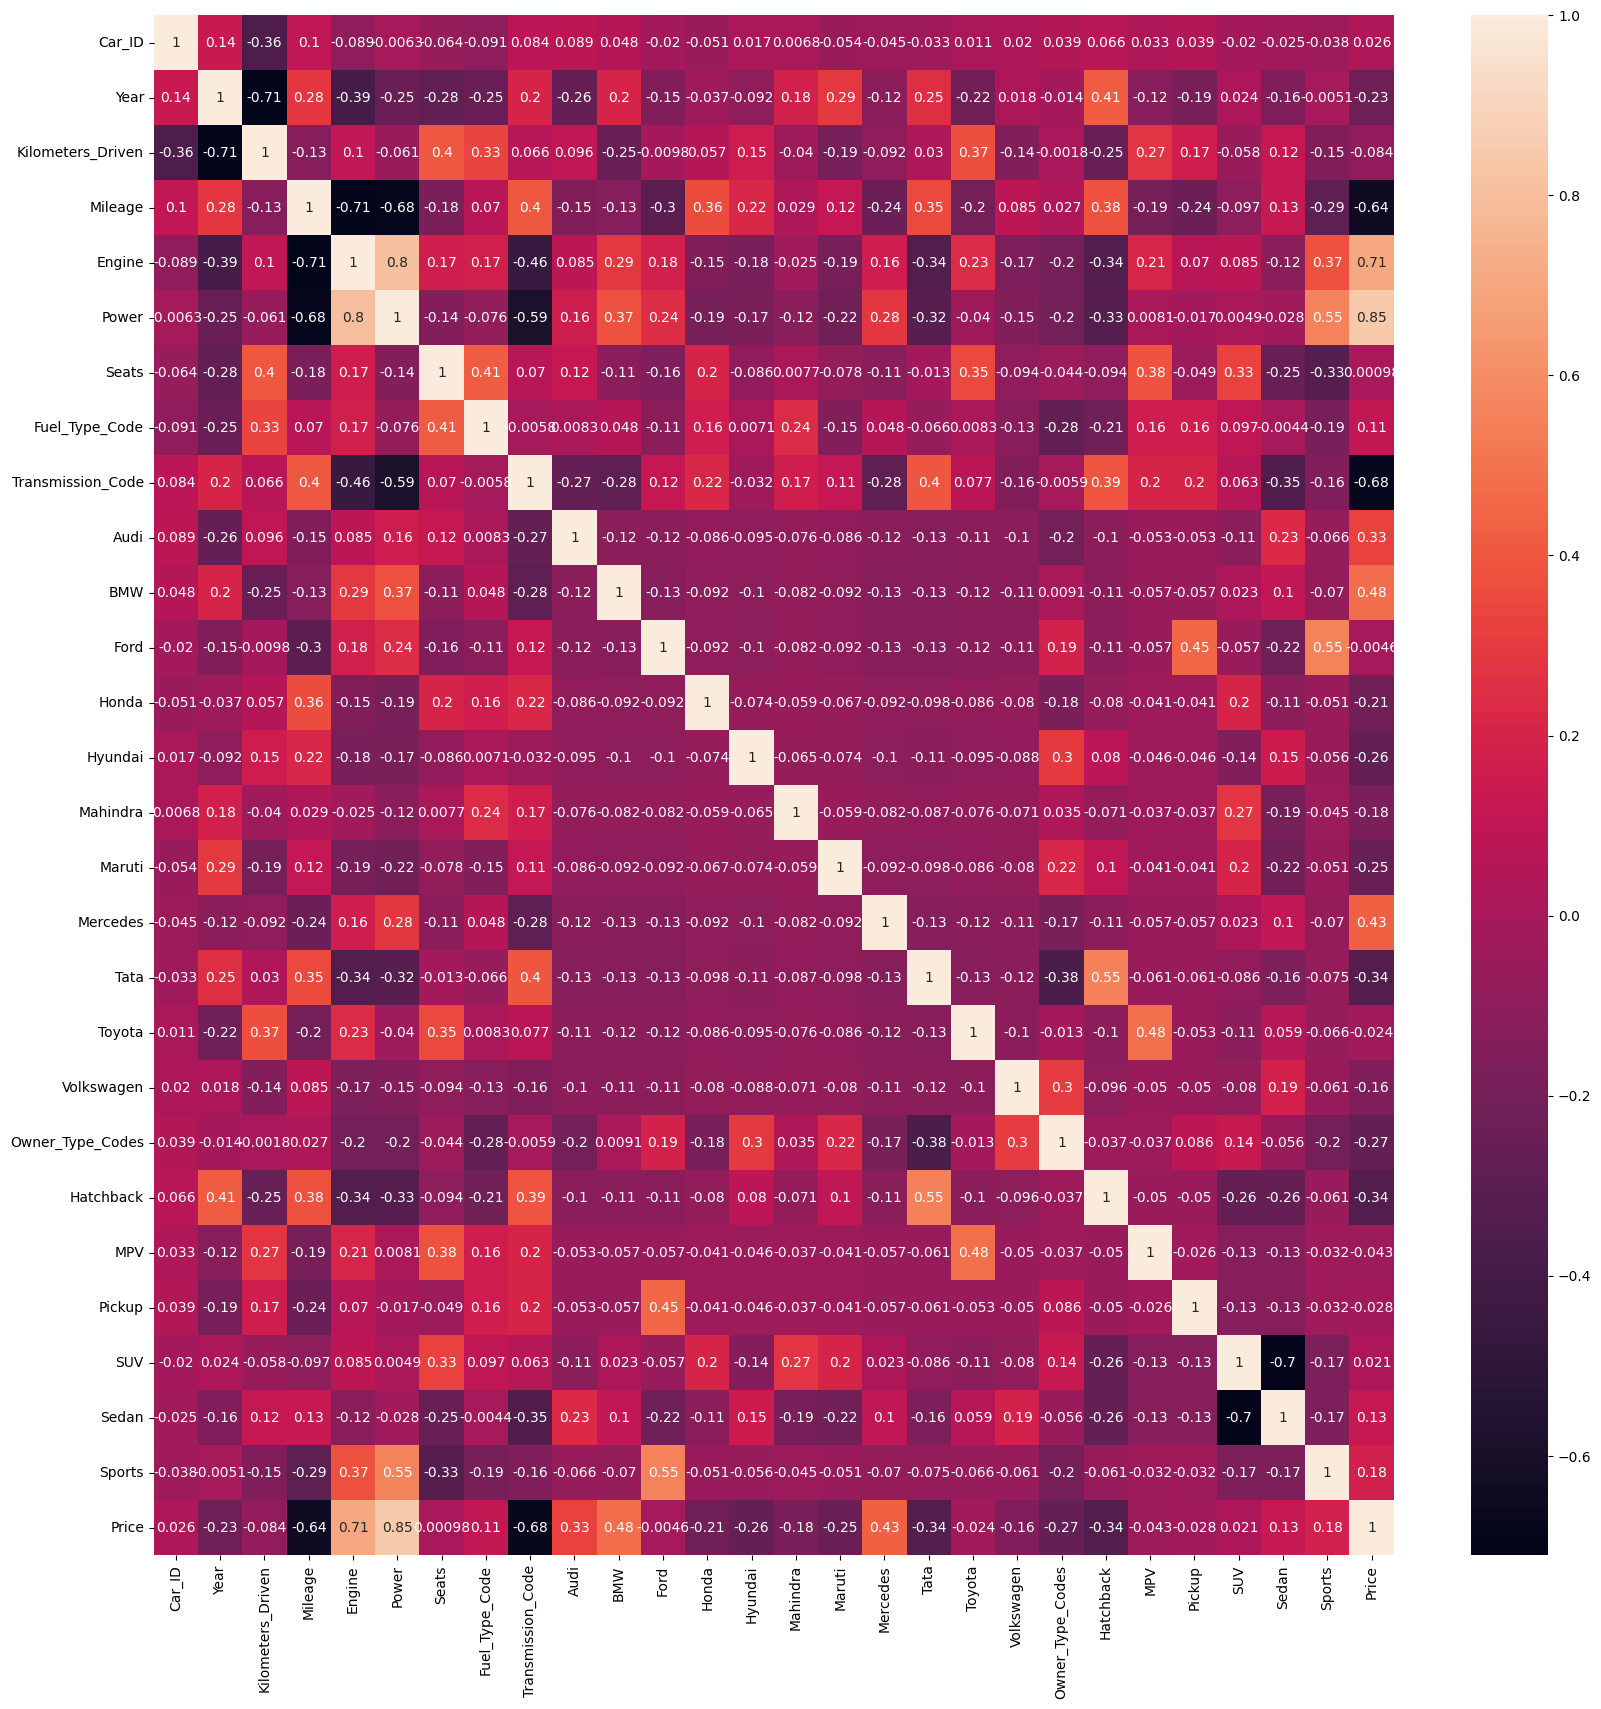

In [89]:
plt.figure(figsize=(20,20))
sns.heatmap(train_set.corr(), annot=True )
plt.show()

In [90]:
price_corr = train_set.corr()['Price']

In [91]:
price_corr.sort_values(ascending=False)

,Price
Price,1.000000
Power,0.849137
Engine,0.710561
BMW,0.477522
Mercedes,0.431606
Audi,0.328858
Sports,0.182007
Sedan,0.125500
Fuel_Type_Code,0.110782
Car_ID,0.025560


In [92]:
# Columns with correlation abs()>0.5
strong_corr = price_corr[price_corr.abs() > 0.5].sort_values(ascending=False)
strong_corr

,Price
Price,1.000000
Power,0.849137
Engine,0.710561
Mileage,-0.638404
Transmission_Code,-0.680731


На основі результатів матриці кореляції, найбільше на значення цільової змінної Price впливають наступні метрики:  
- `Power` (0.85)
- `Engine` (0.71)
- `Transmission_Code` (-0.68)
- `Mileage` (-0.64)

Таким чином бачимо, що кореляційний зв'язок наступний:  
- Зі збільшенням максимальної потужності автомобіля ціна зростає
- Зі збільшенням об'єму двигуна ціна зростає
- Автомобілі з механічною коробкою передач (значення 1 в бінарній колонці `Transmission_Code`) коштують дешевше, ніж на автоматичній
- Зі збільшенням паливоної ефективності (км/л) ціна спадає

## **Завдання 6**.   
Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [93]:
def train_model_show_rmse(inputs, targets):
  model = LinearRegression().fit(inputs, targets)
  predictions = model.predict(inputs)
  loss = root_mean_squared_error(targets, predictions)
  print('Loss:', loss)
  return model, predictions, loss

In [94]:
#price_model, price_predictions
price_model, price_predictions, model_loss = train_model_show_rmse(X_train, y_train)

Loss: 182637.38472928753


In [125]:
# Model coefficients
model_coefs_df = pd.DataFrame({
    'feature': list(X_train.columns) + ['intercept'],
    'weight': np.append(price_model.coef_, price_model.intercept_)
})
model_coefs_df

,feature,weight
0,Car_ID,3.684863e+02
1,Year,2.360538e+04
2,Kilometers_Driven,-6.085958e+00
3,Mileage,-3.691564e+04
4,Engine,-4.416473e+01
5,Power,7.455461e+03
6,Seats,-3.358290e+04
7,Fuel_Type_Code,3.878411e+05
8,Transmission_Code,-2.186085e+05
9,Audi,6.897879e+05


In [95]:
X_test = X_test.select_dtypes(include='number')
X_test.head()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Hatchback,MPV,Pickup,SUV,Sedan,Sports
17,18,2016,38000,15,1395,148,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
41,42,2019,26000,20,1086,68,5,0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0
92,93,2017,32000,18,1598,103,5,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
14,15,2020,18000,19,1462,103,7,0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
68,69,2019,26000,20,1194,94,5,0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0


In [96]:
y_test_pred = price_model.predict(X_test)

In [97]:
y_test_loss = root_mean_squared_error(y_test, y_test_pred)

print('Train set loss:', model_loss)
print('\nTest set loss:', y_test_loss)

Train set loss: 182637.38472928753

Test set loss: 316384.21470651135


In [98]:
train_errors = y_train - model_loss
test_errors = y_test - y_test_loss

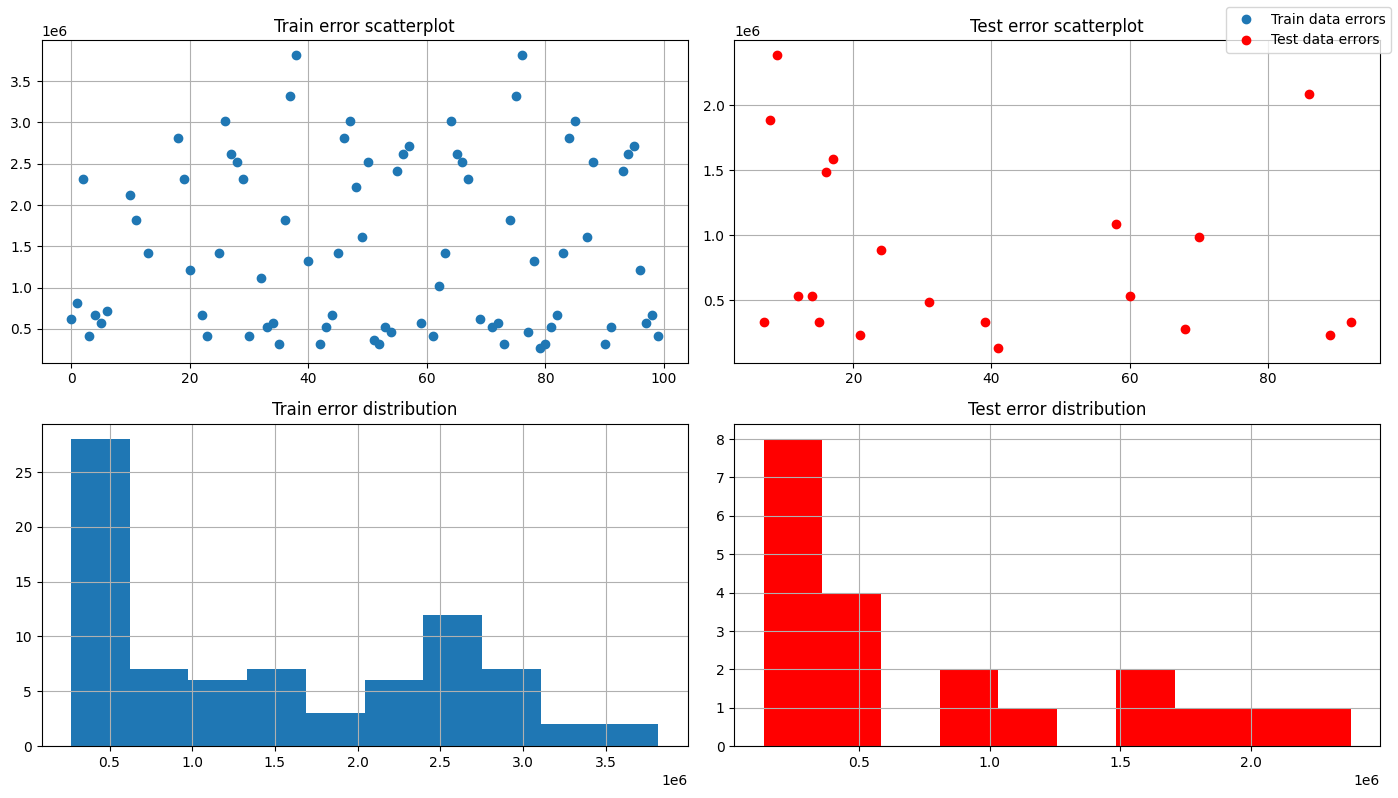

In [122]:
# Візуалізація результатів
fig, ax = plt.subplots(2,2, figsize=(14,8))
ax[0,0].plot(train_errors, 'o', label='Train data errors')
ax[0,1].plot(test_errors, 'o', label='Test data errors', color = 'red')
ax[1,0].hist(train_errors)
ax[1,1].hist(test_errors, color = 'red')

ax[0,0].set_title('Train error scatterplot')
ax[0,1].set_title('Test error scatterplot')
ax[1,0].set_title('Train error distribution')
ax[1,1].set_title('Test error distribution')

ax[0,0].grid(True)
ax[0,1].grid(True)
ax[1,0].grid(True)
ax[1,1].grid(True)

fig.legend()
plt.tight_layout()
plt.show()

Помилки для тренувальних та тестових даних розподілені не нормально. Обидва розподіли мають велику кількість помилок по лівому краю, отже модель має систематичну помилку.

##**Завдання 7**  
 Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [127]:
price_model.coef_, price_model.intercept_

(array([ 3.68486263e+02,  2.36053763e+04, -6.08595842e+00, -3.69156376e+04,
        -4.41647262e+01,  7.45546088e+03, -3.35828951e+04,  3.87841095e+05,
        -2.18608456e+05,  6.89787919e+05,  6.02952550e+05, -9.79547654e+04,
        -2.26404573e+05, -4.33165213e+05, -6.29803610e+05, -3.69519914e+05,
         6.17678476e+05, -2.68223070e+05,  2.56931813e+05, -1.42279612e+05,
        -3.67261567e+04,  3.66138077e+05, -3.28273258e+05,  8.81346615e+04,
         2.53399486e+05,  1.58102382e+05, -5.37501349e+05]),
 np.float64(-46495559.67319358))

In [129]:
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [131]:
X_train_scaled = pd.DataFrame(
  scaler.transform(X_train),
  columns=X_train.columns)

X_test_scaled = pd.DataFrame(
  scaler.transform(X_test),
  columns=X_train.columns)

In [134]:
price_model_scaled, train_scaled_pred, train_scaled_loss = train_model_show_rmse(X_train_scaled, y_train)
test_scaled_pred = price_model_scaled.predict(X_test_scaled)
test_scaled_loss = root_mean_squared_error(y_test, test_scaled_pred)

print('Train Scaled Loss:', train_scaled_loss)
print('Test Scaled Loss:', test_scaled_loss)

Loss: 182637.3847292892
Train Scaled Loss: 182637.3847292892
Test Scaled Loss: 316384.21470651444


In [138]:
# Model coefficients
scaled_model_coefs_df = pd.DataFrame({
    'feature': list(X_train_scaled.columns) + ['intercept'],
    'weight': np.append(price_model_scaled.coef_, price_model_scaled.intercept_),
    'abs_weight': abs(np.append(price_model_scaled.coef_, price_model_scaled.intercept_))
})
scaled_model_coefs_df.sort_values(by='abs_weight', ascending=False)

,feature,weight,abs_weight
27,intercept,1.680000e+06,1.680000e+06
5,Power,6.070480e+05,6.070480e+05
7,Fuel_Type_Code,1.938599e+05,1.938599e+05
9,Audi,1.864285e+05,1.864285e+05
16,Mercedes,1.735741e+05,1.735741e+05
10,BMW,1.689210e+05,1.689210e+05
14,Mahindra,-1.521612e+05,1.521612e+05
26,Sports,-1.324567e+05,1.324567e+05
13,Hyundai,-1.320973e+05,1.320973e+05
3,Mileage,-1.259121e+05,1.259121e+05


In [140]:
# Коефіцієнти, які впливають на збільшення цільової змінної
# в порядку спадання ваги впливу
scaled_model_coefs_df[scaled_model_coefs_df['weight']>0].sort_values(by='abs_weight', ascending=False)

,feature,weight,abs_weight
27,intercept,1.680000e+06,1.680000e+06
5,Power,6.070480e+05,6.070480e+05
7,Fuel_Type_Code,1.938599e+05,1.938599e+05
9,Audi,1.864285e+05,1.864285e+05
16,Mercedes,1.735741e+05,1.735741e+05
10,BMW,1.689210e+05,1.689210e+05
21,Hatchback,5.833257e+04,5.833257e+04
18,Toyota,5.657163e+04,5.657163e+04
24,SUV,4.612698e+04,4.612698e+04
1,Year,2.645586e+04,2.645586e+04


Відповідно до ваги масштабованих коефіцієнтів, найбліьше на збільшення ціни автомобіля впливають:
1. `Power` - потужність двигуна авто
2. `Fuel_Type_Code` - вид палива (оскільки дизелю в оригінальному датасеті відповідє значення 1, то дизельні авто коштують дорожче)
3. Марка авто - `Audi`, `Mersedes`, `BMW` коштують дорожче, ніж інші марки

In [141]:
# Коефіцієнти, які впливають на зменшення цільової змінної
# в порядку спадання ваги впливу
scaled_model_coefs_df[scaled_model_coefs_df['weight']<0].sort_values(by='abs_weight', ascending=False)

,feature,weight,abs_weight
14,Mahindra,-152161.165128,152161.165128
26,Sports,-132456.711984,132456.711984
13,Hyundai,-132097.320033,132097.320033
3,Mileage,-125912.057662,125912.057662
17,Tata,-111314.287208,111314.287208
8,Transmission_Code,-106501.532199,106501.532199
15,Maruti,-105993.777635,105993.777635
22,MPV,-76184.737474,76184.737474
12,Honda,-71351.069333,71351.069333
19,Volkswagen,-59519.583810,59519.583810


Відповідно до ваги масштабованих коефіцієнтів, найбільше на зниження ціни автомобіля впливають:
1. Марка та моделі авто (Mahindra, Hyundai, Mileage, Tata, Maruti) - коштують дешевше, ніж інші марки
2. Тип авто - спорткари - коштують дешевше (логічно це звучить неправдоподібно)
3. Transmission_Code - авто на механіці (значення 1 в категоріальній числовій колонці) коштує дешевше, ніж на автоматі

Щодо коефіцієнтів з іншим впливом, окрім марок та типів авто за моделями, логічним виглядає напрям дії кількості попередніх власників (чим більше було власників, тим авто дешевше), пробігу (чим більший пробіг, тим дешевше авто).  
Щодо впливу об'єму двигуна, зменшення ціни зі збільшенням об'єму виглядає нелогічним.

##**Завдання 8.**   
На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

Перевіримо коефіцієнти на статистичну значущість в даній моделі з масштабованими вагами

### Model 1

In [143]:
X = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train.values,X)
results = ols_model.fit()
results.params

,0
const,1.680000e+06
Car_ID,1.041608e+04
Year,2.645586e+04
Kilometers_Driven,-5.580565e+04
Mileage,-1.259121e+05
Engine,-2.900349e+04
Power,6.070480e+05
Seats,-2.489159e+04
Fuel_Type_Code,1.938599e+05
Transmission_Code,-1.065015e+05


Отримані параметри такі ж, як і в `sklearn`

In [144]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     67.06
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           3.40e-32
Time:                        21:34:24   Log-Likelihood:                -1082.7
No. Observations:                  80   AIC:                             2217.
Df Residuals:                      54   BIC:                             2279.
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.49e+0

Відповідно до звіту, статистично значущими коефіцієнтами є:
1. `const`
2. `Power`
3. `Fuel_Type_Code`
4. `Transmission_Code`
5. `Audi`, `BMV`, `Honda`, `Hyundai`, `Mahindra`, `Maruti`, `Mercedes`, `Tata`, `Volkswagen`
6. `MPV`, `SUV`, `Sports`



##**Завдання 9**.  
 Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

Натренуємо модель на масштабованих ознаках:

In [145]:
X_train_scaled.head()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Hatchback,MPV,Pickup,SUV,Sedan,Sports
0,1.090928,0.568813,-0.693871,0.274862,-0.628491,-0.231967,-0.303562,-0.975305,-0.795395,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,3.229330,0.535303,-0.309662,-0.160128,-0.160128,1.193416,-0.837931,-0.197386
1,0.100381,-0.323442,-0.039533,-0.018324,0.087196,0.247012,-0.303562,1.025320,-0.795395,3.000000,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,-0.309662,-0.994135,-0.309662,-0.160128,-0.160128,-0.837931,1.193416,-0.197386
2,-0.925542,-0.323442,-0.039533,-0.604696,0.111560,0.910213,-0.303562,-0.975305,-0.795395,3.000000,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,-0.309662,-0.994135,-0.309662,-0.160128,-0.160128,-0.837931,1.193416,-0.197386
3,0.065005,-1.215697,0.396692,0.274862,-0.476217,-0.784634,-0.303562,-0.975305,1.257237,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,3.229330,0.535303,-0.309662,-0.160128,-0.160128,-0.837931,1.193416,-0.197386
4,-1.173178,-1.215697,-0.257646,-1.484254,0.122219,0.910213,-0.303562,-0.975305,-0.795395,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,2.808717,-0.377964,-0.333333,-0.309662,0.535303,-0.309662,-0.160128,-0.160128,1.193416,-0.837931,-0.197386


### Model 2

In [148]:
X_train_scaled_sign = X_train_scaled[['Power', 'Fuel_Type_Code', 'Transmission_Code', 'Audi', 'BMW', 'Honda', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Tata', 'Volkswagen', 'MPV', 'SUV', 'Sports']]
X_test_scaled_sign = X_test_scaled[['Power', 'Fuel_Type_Code', 'Transmission_Code', 'Audi', 'BMW', 'Honda', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Tata', 'Volkswagen', 'MPV', 'SUV', 'Sports']]

Тепер перевіримо показники якості моделі

In [153]:
X_sign = sm.add_constant(X_train_scaled_sign)
ols_model_sign = sm.OLS(y_train.values,X_sign)
results_sign = ols_model_sign.fit()

print(results_sign.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     93.90
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           1.31e-37
Time:                        21:54:22   Log-Likelihood:                -1096.0
No. Observations:                  80   AIC:                             2224.
Df Residuals:                      64   BIC:                             2262.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.69e+0

Порівнюючи значення R^2 та adj R^2, бачимо зниження показників з:  

Scaled
```
R-squared: 0.969
Adj. R-squared: 0.954
```
до

Scaled + p < 0.05
```
R-squared: 0.957
Adj. R-squared: 0.946
```
Натомість тепер немає повідомлення про мультиколінеарність та зменшена кількість ознак, на якій будується модель

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

### Model 3

In [156]:
significant_cols = results.pvalues[results.pvalues < 0.25].index.tolist()
if 'const' in significant_cols:
    significant_cols.remove('const')

print(significant_cols)

['Mileage', 'Power', 'Fuel_Type_Code', 'Transmission_Code', 'Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Tata', 'Toyota', 'Volkswagen', 'Hatchback', 'MPV', 'SUV', 'Sports']


In [157]:
X_train_scaled_sign2 = X_train_scaled[significant_cols]
X_test_scaled_sign2 = X_test_scaled[significant_cols]

In [158]:
X_sign2 = sm.add_constant(X_train_scaled_sign2)
ols_model_sign2 = sm.OLS(y_train.values,X_sign2)
results_sign2 = ols_model_sign2.fit()

print(results_sign2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     92.61
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           2.12e-37
Time:                        22:06:11   Log-Likelihood:                -1087.7
No. Observations:                  80   AIC:                             2213.
Df Residuals:                      61   BIC:                             2259.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.49e+0

Отримали менші показники R^2 та adj.R^2, ніж для моделі, яка використовує всі змінні, але більші, ніж модель з порогом стат.значущості 0.05.

Scaled
```
R-squared: 0.969
Adj. R-squared: 0.954
```

Scaled + p < 0.05
```
R-squared: 0.957
Adj. R-squared: 0.946
```

Scaled + p < 0.25
```
R-squared: 0.965
Adj. R-squared: 0.954
```

Також в третій моделі є примітка про мультиколінеарність коефіцієнтів. Бачимо, що серед марок авто всі марки є перелічені серед коефіцієнтів. Через це виникає мультиколінеарність. Приберемо одну з марок (Toyota, у цій моделі вона має меншу стат.значущість, ніж інші марки)

### Model 4

In [159]:
significant_cols3 = results.pvalues[results.pvalues < 0.25].index.tolist()
if 'const' in significant_cols3:
    significant_cols3.remove('const')
if 'Toyota' in significant_cols3:
    significant_cols3.remove('Toyota')

print(significant_cols3)

['Mileage', 'Power', 'Fuel_Type_Code', 'Transmission_Code', 'Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Tata', 'Volkswagen', 'Hatchback', 'MPV', 'SUV', 'Sports']


In [160]:
X_train_scaled_sign3 = X_train_scaled[significant_cols3]
X_test_scaled_sign3 = X_test_scaled[significant_cols3]

In [162]:
X_sign3 = sm.add_constant(X_train_scaled_sign3)
ols_model_sign3 = sm.OLS(y_train.values,X_sign3)
results_sign3 = ols_model_sign3.fit()

print(results_sign3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     92.61
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           2.12e-37
Time:                        22:13:01   Log-Likelihood:                -1087.7
No. Observations:                  80   AIC:                             2213.
Df Residuals:                      61   BIC:                             2259.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.49e+0

Мультиколінеарність зникла.
Порівняння отриманих характеристик всіх 4-х моделей:




Scaled (Multicollinearity)
```
R-squared: 0.969
Adj. R-squared: 0.954
```

Scaled + p < 0.05
```
R-squared: 0.957
Adj. R-squared: 0.946
```

Scaled + p < 0.25 (Multicollinearity)
```
R-squared: 0.965
Adj. R-squared: 0.954
```

Scaled + p < 0.25
```
R-squared: 0.965
Adj. R-squared: 0.954
```

Порівнюючи дві останні моделі, бачимо, що показники якості для них однакові.

Таким чином, найкращою з 4-х моделей є остання, оскільки:
- містить оптимальну кількість ознак (не всі, як у повному масштабованому наборі)
- не містить мультиколінеарності (як третя модель з p < 0.25)
- має найкращий показник Adj.R^2